# Logistic Regression Weather Type Classification

This notebook builds one model only: a **Decision Tree classifier** for the Kaggle Weather Type Classification dataset.  
It follows the same workflow as the Random Forest version so the group project remains consistent across team members.

The notebook includes:
- dataset loading
- feature/target split
- preprocessing with a scikit-learn pipeline
- Decision Tree training
- model evaluation
- cross-validation
- feature importance analysis
- final testing with new weather conditions


## 1. Imports

This cell imports the libraries used for data loading, preprocessing, model building, evaluation, and plotting.  
These tools are enough to take the dataset from raw CSV form all the way to final predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

## 2. Load Dataset

This cell reads the weather dataset from a CSV file.  
If the file name is correct and the CSV is in the same folder as the notebook, the dataset will load into a pandas DataFrame.

In [2]:
DATA_PATH = "weather_classification_data.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## 3. Inspect the dataset structure

This cell checks the shape of the dataset, the data types of each column, and summary statistics.  
This helps us understand what kind of preprocessing is needed before training the model.

In [3]:
print("Dataset shape:", df.shape)
display(df.info())
df.describe(include="all")

Dataset shape: (13200, 11)
<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


None

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,13200.000000,13200.000000,13200.000000,13200.000000,13200,13200.000000,13200.000000,13200,13200.000000,13200,13200
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,3,4
top,NaN,NaN,NaN,NaN,overcast,NaN,NaN,Winter,NaN,inland,Rainy
freq,NaN,NaN,NaN,NaN,6090,NaN,NaN,5610,NaN,4816,3300
mean,19.127576,68.710833,9.832197,53.644394,NaN,1005.827896,4.005758,NaN,5.462917,NaN,NaN
std,17.386327,20.194248,6.908704,31.946541,NaN,37.199589,3.856600,NaN,3.371499,NaN,NaN
min,-25.000000,20.000000,0.000000,0.000000,NaN,800.120000,0.000000,NaN,0.000000,NaN,NaN
25%,4.000000,57.000000,5.000000,19.000000,NaN,994.800000,1.000000,NaN,3.000000,NaN,NaN
50%,21.000000,70.000000,9.000000,58.000000,NaN,1007.650000,3.000000,NaN,5.000000,NaN,NaN
75%,31.000000,84.000000,13.500000,82.000000,NaN,1016.772500,7.000000,NaN,7.500000,NaN,NaN


## 4. Split Features and Target

This cell separates the input columns (**features**) from the output column (**target**).  
The target for this project is `Weather Type`, which is the label the model will learn to predict.

In [4]:
TARGET_COLUMN = "Weather Type"

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COLUMN}', but found: {list(df.columns)}")

X = df.drop(columns=[TARGET_COLUMN])

# Encode the target weather condition labels as numbers.
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[TARGET_COLUMN])
target_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))

print("Feature columns:", list(X.columns))
print("Target encoding:", target_mapping)

Feature columns: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location']
Target encoding: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 10560
Testing rows: 2640


## 4. Preprocessing and Random Forest Pipeline

Numeric columns use median imputation for missing values. Categorical columns use most-frequent imputation and one-hot encoding. Scaling is done as it is required for logistic regression.

In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
condition_features = [col for col in ["Cloud Cover", "Season", "Location"] if col in X.columns]

print("Numeric features:", numeric_features)
print("Categorical features encoded with OneHotEncoder:", categorical_features)
print("Condition features:", condition_features)

Numeric features: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Categorical features encoded with OneHotEncoder: ['Cloud Cover', 'Season', 'Location']
Condition features: ['Cloud Cover', 'Season', 'Location']


C:\Users\ezana\AppData\Local\Temp\ipykernel_32044\3549894073.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


The next cell shows what condition encoding looks like. The model still uses the pipeline below so encoding is learned only from the training data.

In [7]:
if condition_features:
    encoded_condition_preview = pd.get_dummies(
        X[condition_features],
        columns=condition_features,
        dtype=int
    )
    display(encoded_condition_preview.head())
else:
    print("No condition columns found for encoding.")

,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,0,0,0,1,0,0,0,1,0,1,0
1,0,0,0,1,0,1,0,0,0,1,0
2,1,0,0,0,0,1,0,0,0,0,1
3,1,0,0,0,0,1,0,0,1,0,0
4,0,0,1,0,0,0,0,1,0,0,1


In [8]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=0))
])

log_reg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 5. Train Model

In [9]:
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 6. Evaluate Model

In [10]:
y_pred = log_reg_pipeline.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Logistic Regression Accuracy: 0.8561

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.81      0.82      0.81       660
       Rainy       0.82      0.83      0.83       660
       Snowy       0.88      0.91      0.89       660
       Sunny       0.91      0.87      0.89       660

    accuracy                           0.86      2640
   macro avg       0.86      0.86      0.86      2640
weighted avg       0.86      0.86      0.86      2640



In [12]:
cm = confusion_matrix(y_test, y_pred, labels=range(len(target_encoder.classes_)))
cm_df = pd.DataFrame(cm, index=target_encoder.classes_, columns=target_encoder.classes_)
cm_df

,Cloudy,Rainy,Snowy,Sunny
Cloudy,538,78,25,19
Rainy,53,547,44,16
Snowy,24,15,600,21
Sunny,46,25,14,575


## 7. Cross-Validation

In [13]:
cv_scores = cross_val_score(log_reg_pipeline, X, y, cv=5, scoring="accuracy", n_jobs=1)

print("CV scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV standard deviation: {cv_scores.std():.4f}")

CV scores: [0.86704545 0.87234848 0.86704545 0.87234848 0.86780303]
Mean CV accuracy: 0.8693
CV standard deviation: 0.0025


## 8. Feature Importance

In [14]:
feature_names = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = log_reg_pipeline.named_steps["classifier"].coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
10,cat__Cloud Cover_partly cloudy,0.957950
9,cat__Cloud Cover_overcast,0.793524
0,num__Temperature,0.500991
6,num__Visibility (km),0.363451
15,cat__Location_coastal,0.290128
1,num__Humidity,0.278216
11,cat__Season_Autumn,0.241913
12,cat__Season_Spring,0.222965
13,cat__Season_Summer,0.136346
4,num__Atmospheric Pressure,0.077778


<Axes: title={'center': 'Top 20 Logistic Regression Feature Importances'}, ylabel='feature'>

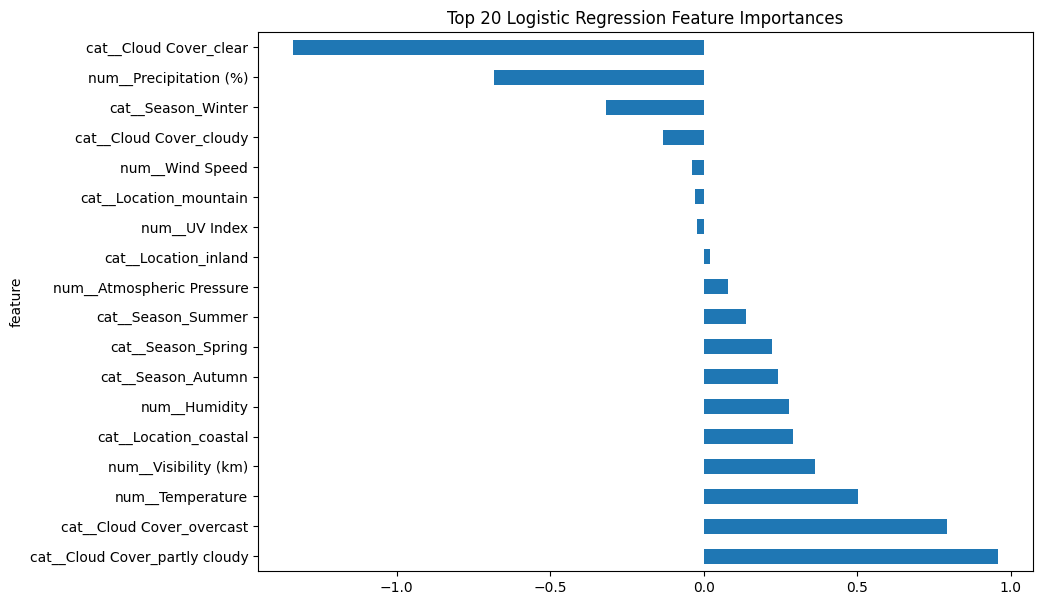

In [15]:
importance_df.head(20).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10, 7),
    legend=False,
    title="Top 20 Logistic Regression Feature Importances"
)

## 9. Final Test With New Weather Conditions

This final test creates new input rows using the same feature columns as the original dataset. The pipeline automatically preprocesses and encodes the condition columns before predicting.

In [17]:
final_test_data = pd.DataFrame([
    {
        "Temperature": 5.0,
        "Humidity": 85,
        "Wind Speed": 12.0,
        "Precipitation (%)": 90.0,
        "Cloud Cover": "overcast",
        "Atmospheric Pressure": 1008.0,
        "UV Index": 1,
        "Season": "Winter",
        "Visibility (km)": 2.0,
        "Location": "inland"
    },
    {
        "Temperature": 31.0,
        "Humidity": 45,
        "Wind Speed": 4.0,
        "Precipitation (%)": 5.0,
        "Cloud Cover": "clear",
        "Atmospheric Pressure": 1020.0,
        "UV Index": 8,
        "Season": "Summer",
        "Visibility (km)": 10.0,
        "Location": "coastal"
    },
    {
        "Temperature": -6.0,
        "Humidity": 92,
        "Wind Speed": 18.0,
        "Precipitation (%)": 95.0,
        "Cloud Cover": "overcast",
        "Atmospheric Pressure": 995.0,
        "UV Index": 0,
        "Season": "Winter",
        "Visibility (km)": 1.0,
        "Location": "mountain"
    }
])

final_test_data = final_test_data[X.columns]
final_encoded_predictions = log_reg_pipeline.predict(final_test_data)
final_label_predictions = target_encoder.inverse_transform(final_encoded_predictions)

final_results = final_test_data.copy()
final_results["Predicted Weather Type"] = final_label_predictions
final_results

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Predicted Weather Type
0,5.0,85,12.0,90.0,overcast,1008.0,1,Winter,2.0,inland,Snowy
1,31.0,45,4.0,5.0,clear,1020.0,8,Summer,10.0,coastal,Sunny
2,-6.0,92,18.0,95.0,overcast,995.0,0,Winter,1.0,mountain,Snowy


In [19]:
final_probabilities = log_reg_pipeline.predict_proba(final_test_data)
probability_df = pd.DataFrame(
    final_probabilities,
    columns=[f"Probability: {label}" for label in target_encoder.classes_]
)

pd.concat([final_results[["Predicted Weather Type"]], probability_df], axis=1)

,Predicted Weather Type,Probability: Cloudy,Probability: Rainy,Probability: Snowy,Probability: Sunny
0,Snowy,0.013748,2.301151e-01,7.560765e-01,0.000060
1,Sunny,0.000125,3.917999e-07,4.772453e-08,0.999875
2,Snowy,0.001815,9.137141e-02,9.068113e-01,0.000003
